In [ ]:
# Data Source
# https://drive.google.com/drive/folders/10SUoVOHnv95fLr-w2HSktjQUd96jXA3U

In [ ]:
# Importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Data Import
data = pd.read_csv('/content/drive/MyDrive/Data science 2026/Data/sms_spam.csv')
data.head()

,type,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
# data dimension
print(f'The data has {data.shape[0]} rows and {data.shape[1]} columns.')

The data has 5574 rows and 2 columns.


In [ ]:
# Data stats
data.describe()

,type,text
count,5574,5574
unique,2,5160
top,ham,"Sorry, I'll call later"
freq,4827,30


In [ ]:
data.groupby('type').describe()

text                                                               
     count unique                                                top freq
type                                                                     
ham   4827   4518                             Sorry, I'll call later   30
spam   747    642  Please call our customer service representativ...    4

In [ ]:
# Creating a length column for further analysis
data['length'] = data['text'].apply(len)
data.head()

,type,text,length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


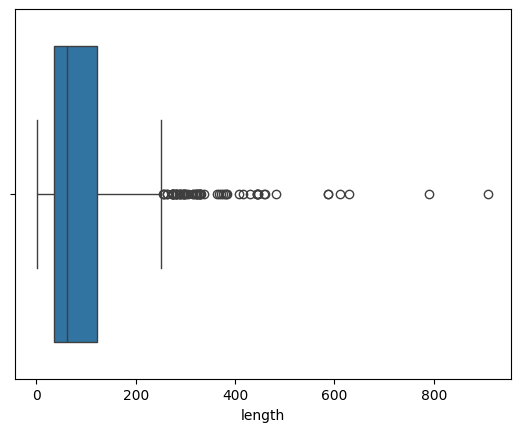

In [ ]:
# box plot to see the distribution of text
sns.boxplot(data['length'], orient='h')
plt.show()

In [ ]:
data['length'].describe()

,length
count,5574.000000
mean,80.444923
std,59.841828
min,2.000000
25%,36.000000
50%,61.000000
75%,122.000000
max,910.000000


In [ ]:
# text with maximum length
data[data['length'] == 910]['text'].iloc[0]

"For me the love should start with attraction.i should feel that I need her every time around me.she should be the first thing which comes in my thoughts.I would start the day and end it with her.she should be there every time I dream.love will be then when my every breath has her name.my life should happen around her.my life will be named to her.I would cry for her.will give all my happiness and take all her sorrows.I will be ready to fight with anyone for her.I will be in love when I will be doing the craziest things for her.love will be when I don't have to proove anyone that my girl is the most beautiful lady on the whole planet.I will always be singing praises for her.love will be when I start up making chicken curry and end up makiing sambar.life will be the most beautiful then.will get every morning and thank god for the day because she is with me.I would like to say a lot..will tell later.."

In [ ]:
# testing

In [ ]:
# Text Preprocessing
import string
message = 'This is a## dummy me%ssage to showcase the ?*ability of !the module%$'
no_punc = [word for word in message if word not in string.punctuation]
out_message = ''.join(no_punc)
print(out_message)

This is a dummy message to showcase the ability of the module


In [ ]:
# import required nlp libraries
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
def text_process(mess):
    no_punc = [letter for letter in mess if letter not in string.punctuation]
    out_message = ''.join(no_punc)
    return [word for word in out_message.split() if word.lower() not in stopwords.words('english')]

In [ ]:
data['text'].head().apply(text_process)

,text
0,"[Go, jurong, point, crazy, Available, bugis, n..."
1,"[Ok, lar, Joking, wif, u, oni]"
2,"[Free, entry, 2, wkly, comp, win, FA, Cup, fin..."
3,"[U, dun, say, early, hor, U, c, already, say]"
4,"[Nah, dont, think, goes, usf, lives, around, t..."


In [ ]:
data.head()

,type,text,length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [ ]:
# Word embedding
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

In [ ]:
# To extract vocabulary
bow = CountVectorizer(analyzer=text_process,ngram_range= (2, 2)).fit(data['text'])
print(len(bow.vocabulary_))

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:533: UserWarning: The parameter 'ngram_range' will not be used since 'analyzer' is callable'
  warnings.warn(


11401


In [ ]:
print(bow.vocabulary_)

{'Go': 2058, 'jurong': 7537, 'point': 8899, 'crazy': 5760, 'Available': 1110, 'bugis': 5212, 'n': 8318, 'great': 6925, 'world': 11142, 'la': 7650, 'e': 6205, 'buffet': 5211, 'Cine': 1483, 'got': 6894, 'amore': 4647, 'wat': 10945, 'Ok': 3059, 'lar': 7683, 'Joking': 2445, 'wif': 11051, 'u': 10679, 'oni': 8572, 'Free': 1939, 'entry': 6319, '2': 423, 'wkly': 11102, 'comp': 5611, 'win': 11063, 'FA': 1831, 'Cup': 1551, 'final': 6545, 'tkts': 10493, '21st': 443, 'May': 2799, '2005': 430, 'Text': 3948, '87121': 871, 'receive': 9234, 'questionstd': 9141, 'txt': 10667, 'rateTCs': 9182, 'apply': 4725, '08452810075over18s': 73, 'U': 4062, 'dun': 6192, 'say': 9536, 'early': 6210, 'hor': 7172, 'c': 5254, 'already': 4623, 'Nah': 2943, 'dont': 6112, 'think': 10414, 'goes': 6865, 'usf': 10780, 'lives': 7824, 'around': 4771, 'though': 10431, 'FreeMsg': 1941, 'Hey': 2220, 'darling': 5855, '3': 543, 'weeks': 10991, 'word': 11129, 'back': 4887, 'Id': 2344, 'like': 7782, 'fun': 6743, 'still': 10075, 'Tb': 3

In [ ]:
message_bow = bow.transform(data['text'])
message_bow

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 50544 stored elements and shape (5574, 11401)>

In [ ]:
print(message_bow)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 50544 stored elements and shape (5574, 11401)>
  Coords	Values
  (0, 1110)	1
  (0, 1483)	1
  (0, 2058)	1
  (0, 4647)	1
  (0, 5211)	1
  (0, 5212)	1
  (0, 5760)	1
  (0, 6205)	1
  (0, 6894)	1
  (0, 6925)	1
  (0, 7537)	1
  (0, 7650)	1
  (0, 8318)	1
  (0, 8899)	1
  (0, 10945)	1
  (0, 11142)	1
  (1, 2445)	1
  (1, 3059)	1
  (1, 7683)	1
  (1, 8572)	1
  (1, 10679)	1
  (1, 11051)	1
  (2, 73)	1
  (2, 423)	1
  (2, 430)	1
  :	:
  (5570, 6679)	1
  (5570, 6870)	1
  (5570, 7145)	1
  (5570, 11394)	1
  (5571, 3223)	1
  (5571, 3716)	1
  (5571, 8234)	1
  (5571, 10181)	1
  (5572, 4502)	1
  (5572, 5049)	1
  (5572, 5245)	1
  (5572, 6270)	1
  (5572, 6687)	1
  (5572, 6787)	1
  (5572, 6972)	1
  (5572, 7273)	1
  (5572, 7380)	1
  (5572, 7782)	1
  (5572, 8402)	1
  (5572, 9897)	1
  (5572, 10768)	1
  (5572, 10986)	1
  (5573, 3426)	1
  (5573, 8330)	1
  (5573, 10629)	1


In [ ]:
tfidf_transformer = TfidfTransformer().fit(message_bow)
message_tfid = tfidf_transformer.transform(message_bow)
message_tfid.shape

(5574, 11401)

In [ ]:
print(message_tfid)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 50544 stored elements and shape (5574, 11401)>
  Coords	Values
  (0, 1110)	0.28828459898893377
  (0, 1483)	0.3125357690523998
  (0, 2058)	0.2420402708624076
  (0, 4647)	0.3125357690523998
  (0, 5211)	0.29834974396666064
  (0, 5212)	0.26870529747253846
  (0, 5760)	0.24984740383972864
  (0, 6205)	0.1891588424976738
  (0, 6894)	0.15158985673221018
  (0, 6925)	0.18347278575774867
  (0, 7537)	0.3125357690523998
  (0, 7650)	0.2640334289254678
  (0, 8318)	0.17047287571100914
  (0, 8899)	0.24704694620162193
  (0, 10945)	0.19073747309736885
  (0, 11142)	0.23026810232333333
  (1, 2445)	0.5619816842520484
  (1, 3059)	0.29120672453799534
  (1, 7683)	0.37674276971445636
  (1, 8572)	0.5043365091357772
  (1, 10679)	0.20637541507921356
  (1, 11051)	0.4006170106480546
  (2, 73)	0.2253848534794693
  (2, 423)	0.0963965137623166
  (2, 430)	0.21778125645306098
  :	:
  (5570, 6679)	0.4778073440068897
  (5570, 6870)	0.31368079307544483
  (5570, 71

Simple ML Model

In [ ]:
from sklearn.naive_bayes import MultinomialNB              # bag of word
spam_model = MultinomialNB().fit(message_bow, data['type'])

In [ ]:
prediction = spam_model.predict(message_bow)
prediction

array(['ham', 'ham', 'spam', ..., 'ham', 'ham', 'ham'], dtype='<U4')

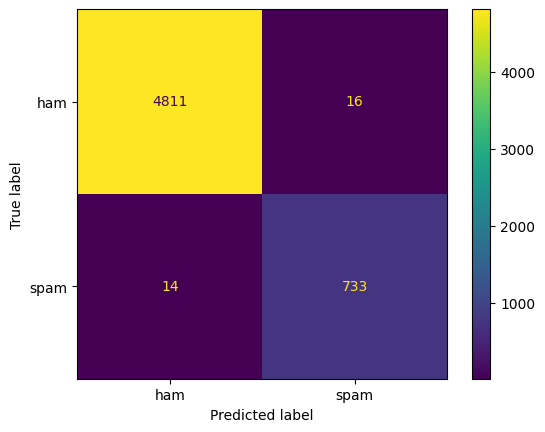

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
cm = ConfusionMatrixDisplay.from_predictions(data['type'], prediction)

In [ ]:
tfidf_transformer = TfidfTransformer().fit(message_bow)           # tfidf
message_tfid = tfidf_transformer.transform(message_bow)

In [ ]:
from sklearn.naive_bayes import MultinomialNB
spam_model = MultinomialNB().fit(message_tfid, data['type'])

In [ ]:
prediction = spam_model.predict(message_tfid)
prediction

array(['ham', 'ham', 'spam', ..., 'ham', 'ham', 'ham'], dtype='<U4')

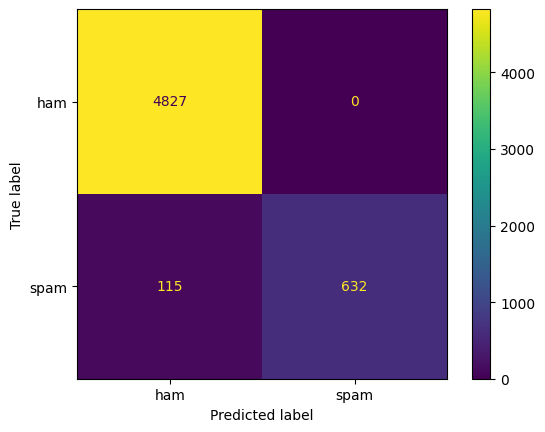

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
cm = ConfusionMatrixDisplay.from_predictions(data['type'], prediction)

In [ ]:
new_message = ['you won the prize']
processed_new_message = bow.transform(new_message)
new_message_tfidf = tfidf_transformer.transform(processed_new_message)
prediction = spam_model.predict(new_message_tfidf)
print(prediction)

['spam']
